In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../human_data/human_cohort2.csv', index_col=0)
print('Shape:', df.shape)
df.head(3)

Shape: (184639, 18)


,true_log_time,prob_flip,prob_rwd,rand_flip,rand_reward,subject_id,session,score,active_side,side,active_side_poke,reward,experimental_group,run,protocol,streak,more_than_2_sessions,matched
0,2022-02-28 16:17:25,0.15,0.45,0.615166,0.573979,001_R001,1,0,0,0,1,0,Remitted,1,1,1,0,1
1,2022-02-28 16:17:26,0.15,0.45,0.556584,0.990301,001_R001,1,0,0,0,1,0,Remitted,1,1,1,0,1
2,2022-02-28 16:17:26,0.15,0.45,0.607029,0.039498,001_R001,1,10,0,0,1,1,Remitted,1,1,1,0,1


## subject_id

In [2]:
print('Number of unique subjects:', df['subject_id'].nunique())
print('\nAll subject IDs:')
df['subject_id'].unique()

Number of unique subjects: 116

All subject IDs:


array(['001_R001', '002_D001', '003_H001', '004_D002', '005_D003',
       '006_D004', '007_R002', '008_D005', '009_H002', '010_R003',
       '011_D006', '012_D007', '013_H003', '014_H004', '015_H005',
       '016_D008', '017_D009', '019_D011', '020_D012', '021_R004',
       '022_R005', '023_H006', '024_R006', '025_D013', '026_H007',
       '027_H008', '028_D014', '030_H010', '031_R007', '032_H011',
       '033_D015', '034_D016', '035_H012', '036_D017', '037_D018',
       '038_D019', '039_H013', '040_H014', '041_R008', '043_R010',
       '044_R011', '046_D021', '047_D022', '048_H015', '049_H016',
       '050_H017', '051_R012', '052_H018', '054_R014', '055_H020',
       '056_H021', '057_H022', '058_H023', '059_H024', '061_H025',
       '062_H026', '064_H028', '065_H029', '067_H030', '068_R016',
       '069_R017', '070_R018', '071_R019', '072_H031', '073_H032',
       '074_R020', '075_H033', '076_H034', '077_R021', '078_H035',
       '079_R022', '080_R023', '082_R025', '084_R026', '085_R0

## score
Score is cumulative within a run. Each reward = +10 points.

Points per reward: 10 (confirmed from score diffs)

count    231.000000
mean     795.454545
std        4.990109
min      790.000000
25%      790.000000
50%      800.000000
75%      800.000000
max      800.000000
Name: score, dtype: float64


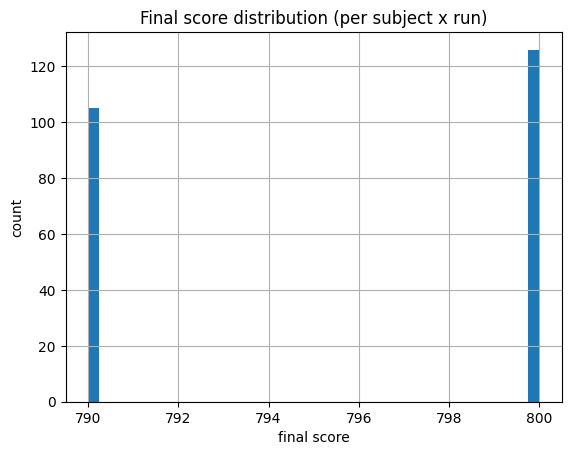

In [3]:
final_scores = df.groupby(['subject_id', 'run'])['score'].last()
print('Points per reward: 10 (confirmed from score diffs)')
print()
print(final_scores.describe())
final_scores.hist(bins=40)
plt.xlabel('final score')
plt.ylabel('count')
plt.title('Final score distribution (per subject x run)')
plt.show()

## active_side and side
Values are 0 or 1 (left/right).

In [4]:
print('active_side unique values:', sorted(df['active_side'].unique()))
print('side unique values:', sorted(df['side'].unique()))

active_side unique values: [np.int64(0), np.int64(1)]
side unique values: [np.int64(0), np.int64(1)]


         earned                                                n_rewards  \
          count   mean  std    min    25%    50%    75%    max     count   
protocol                                                                   
1         452.0  387.9  8.4  230.0  390.0  390.0  390.0  390.0     452.0   
2         452.0  395.9  9.3  390.0  390.0  400.0  400.0  560.0     452.0   

                                                   
          mean  std   min   25%   50%   75%   max  
protocol                                           
1         38.9  0.8  23.0  39.0  39.0  39.0  40.0  
2         40.6  0.9  40.0  40.0  41.0  41.0  57.0  


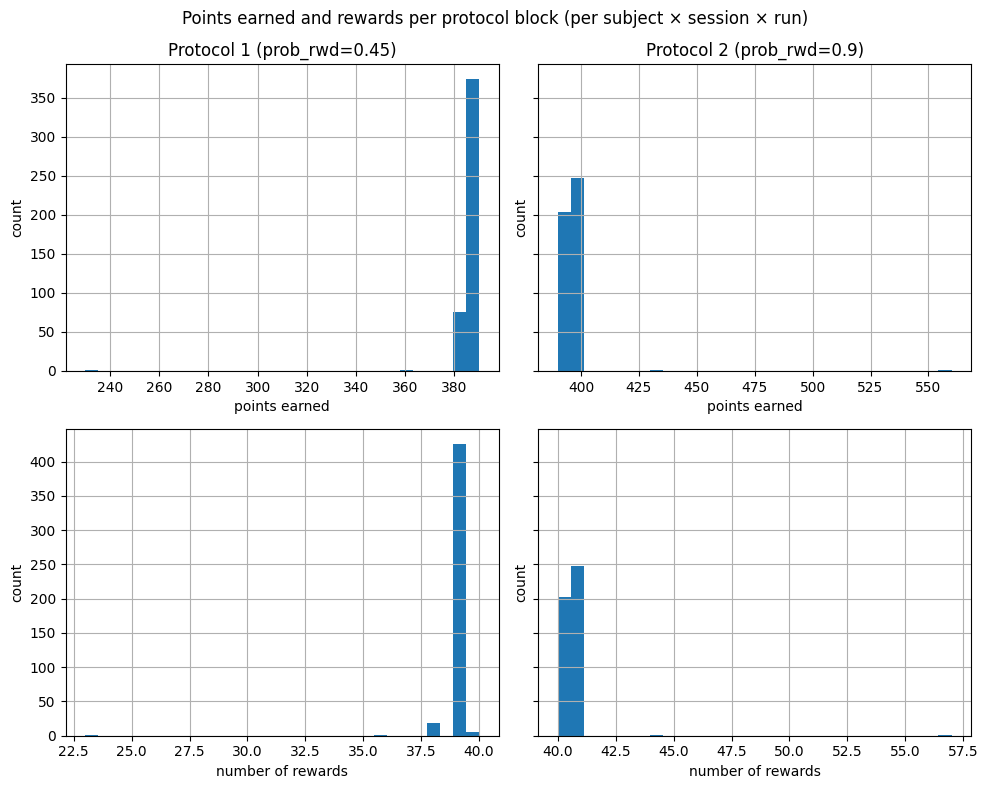

In [5]:
block_scores = df.groupby(['subject_id', 'session', 'run', 'protocol'])['score'].agg(['first', 'last'])
block_scores['earned'] = block_scores['last'] - block_scores['first']
block_rewards = df.groupby(['subject_id', 'session', 'run', 'protocol'])['reward'].sum()
block_scores['n_rewards'] = block_rewards
print(block_scores.groupby('protocol')[['earned', 'n_rewards']].describe().round(1))

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey='row')
for col, (proto, grp) in enumerate(block_scores.groupby('protocol')):
    label = f'Protocol {proto} (prob_rwd={0.45 if proto==1 else 0.9})'
    grp['earned'].hist(bins=30, ax=axes[0, col])
    axes[0, col].set_title(label)
    axes[0, col].set_xlabel('points earned')
    axes[0, col].set_ylabel('count')

    grp['n_rewards'].hist(bins=30, ax=axes[1, col])
    axes[1, col].set_xlabel('number of rewards')
    axes[1, col].set_ylabel('count')

plt.suptitle('Points earned and rewards per protocol block (per subject × session × run)')
plt.tight_layout()
plt.show()

## Score by protocol block\nSince score is cumulative across protocols within a run, we compute points *earned* within each block (last - first score of that block).

## active_side_poke
Expected: 1 if active_side == side, else 0.

In [6]:
expected = (df['active_side'] == df['side']).astype(int)
matches = (expected == df['active_side_poke']).all()
print('active_side_poke always equals (active_side == side):', matches)
if not matches:
    mismatches = df[expected != df['active_side_poke']]
    print(f'  Mismatches: {len(mismatches)} rows')
    display(mismatches[['active_side','side','active_side_poke']].head())

active_side_poke always equals (active_side == side): True


## reward
Expected: only possible when active_side_poke == 1. Reward rate depends on protocol (prob_rwd = 0.45 or 0.9).

In [7]:
reward_inactive = df[(df['active_side_poke'] == 0) & (df['reward'] == 1)]
print('Rows with reward=1 but active_side_poke=0:', len(reward_inactive))

print('\nReward rate by prob_rwd (protocol):')
active_pokes = df[df['active_side_poke'] == 1]
for p, grp in active_pokes.groupby('prob_rwd'):
    rate = grp['reward'].mean()
    print(f'  prob_rwd={p}: reward rate = {rate:.3f}  (n={len(grp):,})')

Rows with reward=1 but active_side_poke=0: 0

Reward rate by prob_rwd (protocol):
  prob_rwd=0.45: reward rate = 0.439  (n=40,094)
  prob_rwd=0.9: reward rate = 0.895  (n=20,509)


## experimental_group

In [8]:
print('Unique groups:', df['experimental_group'].unique())
print('\nSubjects per group:')
df.groupby('experimental_group')['subject_id'].nunique()

Unique groups: ['Remitted' 'Depressed' 'Healthy']

Subjects per group:


experimental_group
Depressed    35
Healthy      40
Remitted     41
Name: subject_id, dtype: int64

## session, run, protocol — relationships
Hierarchy: **subject -> session -> run**, with both protocols (1 and 2) always present within each run.

In [9]:
# Protocol parameters
print('Protocol parameters:')
display(df.groupby('protocol')[['prob_rwd', 'prob_flip']].first())

Protocol parameters:


,prob_rwd,prob_flip
protocol,,
1,0.45,0.15
2,0.90,0.30


In [10]:
# Sessions per subject (mostly 2, a few have 1 or 3)
print('Sessions per subject:')
print(df.groupby('subject_id')['session'].nunique().value_counts().sort_index().rename('n_subjects'))

# Runs per session (almost always 2)
print('\nRuns per (subject, session):')
print(df.groupby(['subject_id', 'session'])['run'].nunique().value_counts().sort_index().rename('n_subject_sessions'))

# Protocols per run (always both 1 and 2)
print('\nProtocols per (subject, session, run):')
print(df.groupby(['subject_id', 'session', 'run'])['protocol'].nunique().value_counts().sort_index().rename('n_runs'))

Sessions per subject:
session
1      8
2    105
3      3
Name: n_subjects, dtype: int64

Runs per (subject, session):
run
1      2
2    225
Name: n_subject_sessions, dtype: int64

Protocols per (subject, session, run):
protocol
2    452
Name: n_runs, dtype: int64


In [11]:
df['true_log_time'] = pd.to_datetime(df['true_log_time'])

# --- Sessions: different days? ---
results = []
for subj, grp in df.groupby('subject_id'):
    sess_days = grp.groupby('session')['true_log_time'].apply(lambda x: x.dt.date.min()).sort_index()
    for i in range(1, len(sess_days)):
        results.append((sess_days.iloc[i] - sess_days.iloc[i-1]).days)

days_between_sessions = pd.Series(results)
print('Days between consecutive sessions (across all subjects):')
print(days_between_sessions.describe().round(1))

# --- Runs: same day within a session? ---
run_dates = df.groupby(['subject_id','session','run'])['true_log_time'].apply(lambda x: x.dt.date.min()).reset_index()
run_dates.columns = ['subject_id','session','run','date']
run_pivot = run_dates.pivot_table(index=['subject_id','session'], columns='run', values='date', aggfunc='first').dropna()
run_pivot.columns = ['run1_date','run2_date']
same_day_runs = (run_pivot['run1_date'] == run_pivot['run2_date']).value_counts()
print('\nRun 1 and run 2 on the same day (per session)?')
print(same_day_runs)

# --- Protocols: consecutive within a run (seconds gap)? ---
proto_times = df.groupby(['subject_id','session','run','protocol'])['true_log_time'].agg(['min','max']).reset_index()
p1 = proto_times[proto_times['protocol']==1][['subject_id','session','run','max']].rename(columns={'max':'end_p1'})
p2 = proto_times[proto_times['protocol']==2][['subject_id','session','run','min']].rename(columns={'min':'start_p2'})
merged = p1.merge(p2, on=['subject_id','session','run'])
merged['gap_s'] = (merged['start_p2'] - merged['end_p1']).dt.total_seconds()
print('\nSeconds between end of protocol 1 and start of protocol 2 (within a run):')
print(merged['gap_s'].describe().round(1))

Days between consecutive sessions (across all subjects):
count    111.0
mean      50.1
std       12.3
min       35.0
25%       42.0
50%       46.0
75%       52.5
max      100.0
dtype: float64

Run 1 and run 2 on the same day (per session)?
True    225
Name: count, dtype: int64

Seconds between end of protocol 1 and start of protocol 2 (within a run):
count    452.0
mean       1.1
std        4.8
min        0.0
25%        0.0
50%        1.0
75%        1.0
max      100.0
Name: gap_s, dtype: float64


## Temporal structure of sessions, runs, and protocols

In [12]:
# Anomaly: session(s) with only 1 run
runs_per_session = df.groupby(['subject_id', 'session'])['run'].nunique()
anomalies = runs_per_session[runs_per_session < 2]
print('Subject-sessions with fewer than 2 runs:')
print(anomalies if len(anomalies) else 'None')

Subject-sessions with fewer than 2 runs:
subject_id  session
005_D003    1          1
043_R010    1          1
Name: run, dtype: int64


## streak
**Streak = bout number** (not poke count within a bout). All pokes in a consecutive block on the same side share the same streak value; it increments by 1 on each side switch.

In [13]:
# streak = bout number: all pokes in one side-visit share the same value,
# incrementing by 1 each time the subject switches sides.
# Verify on one block (subject/session/run/protocol).
example = df[
    (df['subject_id'] == '001_R001') & (df['session'] == 1) &
    (df['run'] == 1) & (df['protocol'] == 1)
].copy().reset_index(drop=True)

bout, recomputed = 1, []
for i in range(len(example)):
    if i > 0 and example.loc[i, 'side'] != example.loc[i-1, 'side']:
        bout += 1
    recomputed.append(bout)

example['streak_recomputed'] = recomputed
match = (example['streak'] == example['streak_recomputed']).all()
print('Streak matches bout number (within one block):', match)
if not match:
    diff = example[example['streak'] != example['streak_recomputed']]
    print(f'Mismatches: {len(diff)} rows')
    display(diff[['side', 'streak', 'streak_recomputed']].head(10))

print('\nStreak (bout number) range across all data:')
print(df['streak'].describe())

Streak matches bout number (within one block): True

Streak (bout number) range across all data:
count    184639.000000
mean          8.946111
std           6.338999
min           1.000000
25%           4.000000
50%           8.000000
75%          12.000000
max          78.000000
Name: streak, dtype: float64



Max streak (bout) number per block (subject/session/run/protocol):
count    904.000000
mean      16.586283
std        6.812410
min        6.000000
25%       13.000000
50%       15.000000
75%       18.000000
max       78.000000
Name: streak, dtype: float64


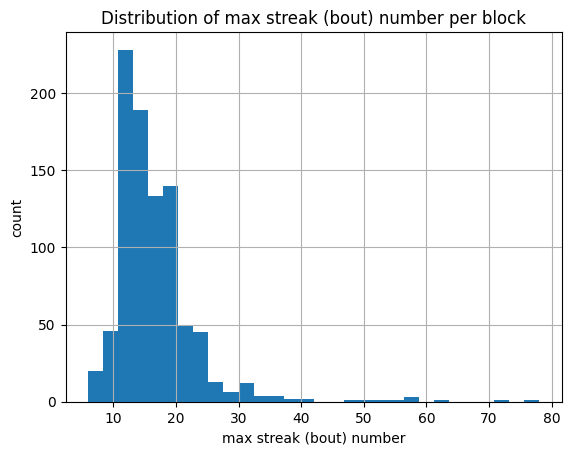

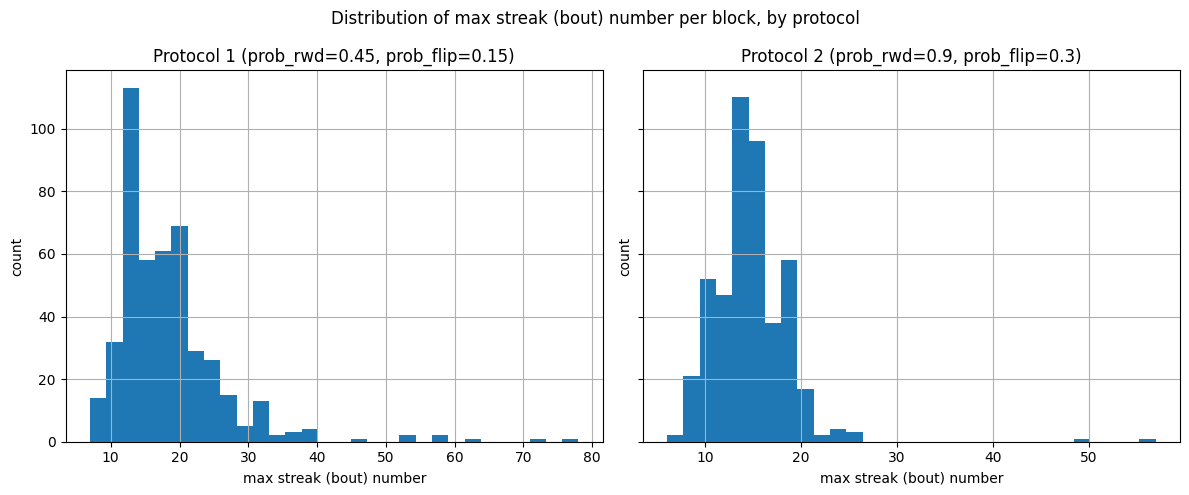

In [17]:
# histogram of maximum streak number in a block (subject/session/run/protocol)
max_streaks = df.groupby(['subject_id', 'session', 'run', 'protocol'])['streak'].max()
print('\nMax streak (bout) number per block (subject/session/run/protocol):')
print(max_streaks.describe())
max_streaks.hist(bins=30)
plt.xlabel('max streak (bout) number')
plt.ylabel('count')
plt.title('Distribution of max streak (bout) number per block')
plt.show()

# now per protocol, as a dividied plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for col, (proto, grp) in enumerate(df.groupby('protocol')):
    max_streaks = grp.groupby(['subject_id', 'session', 'run', 'protocol'])['streak'].max()
    label = f'Protocol {proto} (prob_rwd={0.45 if proto==1 else 0.9}, prob_flip={0.15 if proto==1 else 0.3})'
    max_streaks.hist(bins=30, ax=axes[col])
    axes[col].set_title(label)
    axes[col].set_xlabel('max streak (bout) number')
    axes[col].set_ylabel('count')
plt.suptitle('Distribution of max streak (bout) number per block, by protocol')
plt.tight_layout()
plt.show()  
 


Number of rows per block (subject/session/run/protocol):
count     904.000000
mean      204.246681
std       103.331001
min        51.000000
25%       140.750000
50%       183.000000
75%       241.250000
max      1099.000000
dtype: float64


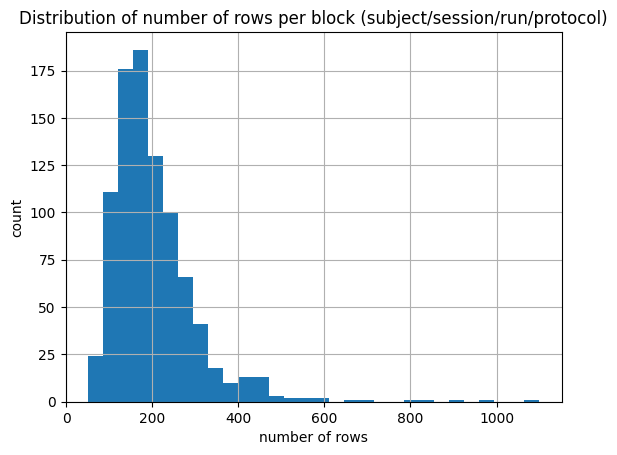

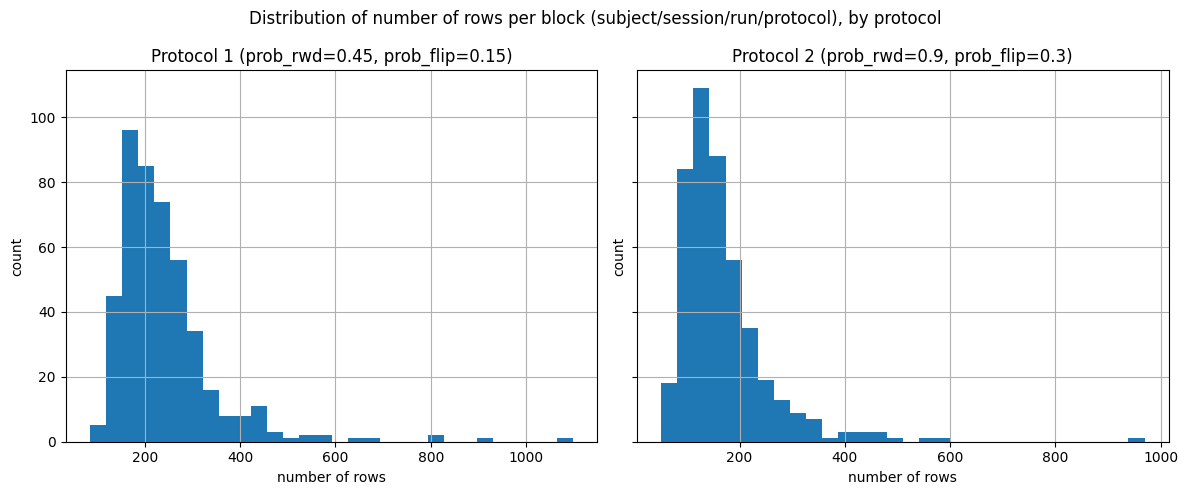


Max streak (bout) number per block, by protocol:
Protocol 1 (prob_rwd=0.45, prob_flip=0.15):
count    452.0
mean      18.4
std        8.3
min        7.0
25%       13.0
50%       17.0
75%       21.0
max       78.0
Name: streak, dtype: float64
  95th percentile: 32.0

Protocol 2 (prob_rwd=0.9, prob_flip=0.3):
count    452.0
mean      14.7
std        4.1
min        6.0
25%       12.0
50%       14.0
75%       17.0
max       57.0
Name: streak, dtype: float64
  95th percentile: 20.0


Number of rows per block (subject/session/run/protocol), by protocol:
Protocol 1 (prob_rwd=0.45, prob_flip=0.15):
count     452.0
mean      240.5
std       106.7
min        85.0
25%       174.0
50%       218.0
75%       274.0
max      1099.0
dtype: float64
  95th percentile: 431.4

Protocol 2 (prob_rwd=0.9, prob_flip=0.3):
count    452.0
mean     168.0
std       85.8
min       51.0
25%      115.0
50%      148.0
75%      191.5
max      969.0
dtype: float64
  95th percentile: 316.0



In [21]:
# distribution of number of rows per block (subject/session/run/protocol)
rows_per_block = df.groupby(['subject_id', 'session', 'run', 'protocol']).size()
print('\nNumber of rows per block (subject/session/run/protocol):')
print(rows_per_block.describe())
rows_per_block.hist(bins=30)
plt.xlabel('number of rows')
plt.ylabel('count')
plt.title('Distribution of number of rows per block (subject/session/run/protocol)')
plt.show()

# now per protocol
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for col, (proto, grp) in enumerate(df.groupby('protocol')):
    rows_per_block = grp.groupby(['subject_id', 'session', 'run', 'protocol']).size()
    label = f'Protocol {proto} (prob_rwd={0.45 if proto==1 else 0.9}, prob_flip={0.15 if proto==1 else 0.3})'
    rows_per_block.hist(bins=30, ax=axes[col])
    axes[col].set_title(label)
    axes[col].set_xlabel('number of rows')
    axes[col].set_ylabel('count')
plt.suptitle('Distribution of number of rows per block (subject/session/run/protocol), by protocol')
plt.tight_layout()
plt.show()

# describe both
print('\nMax streak (bout) number per block, by protocol:')
for proto, grp in df.groupby('protocol'):
    max_streaks = grp.groupby(['subject_id', 'session', 'run', 'protocol'])['streak'].max()
    print(f'Protocol {proto} (prob_rwd={0.45 if proto==1 else 0.9}, prob_flip={0.15 if proto==1 else 0.3}):')
    print(max_streaks.describe().round(1))
    # show also 95th percentile to get a sense of the tail
    print(f'  95th percentile: {max_streaks.quantile(0.95):.1f}')
    print()

print('\nNumber of rows per block (subject/session/run/protocol), by protocol:')
for proto, grp in df.groupby('protocol'):
    rows_per_block = grp.groupby(['subject_id', 'session', 'run', 'protocol']).size()
    print(f'Protocol {proto} (prob_rwd={0.45 if proto==1 else 0.9}, prob_flip={0.15 if proto==1 else 0.3}):')
    print(rows_per_block.describe().round(1))
    # show also 95th percentile to get a sense of the tail
    print(f'  95th percentile: {rows_per_block.quantile(0.95):.1f}')
    print()